In [1]:
# Step 0: Install Required Libraries
# Run this once if Qiskit is not already installed
!pip install qiskit matplotlib pylatexenc --quiet

In [5]:
# Step 1: Import Libraries
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.quantum_info import Statevector
from IPython.display import display
import matplotlib.pyplot as plt
import random

=== Step 1: Initial 3-Puzzle State Circuit ===


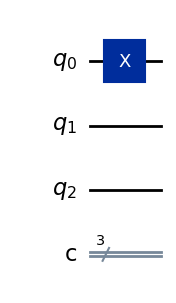

=== Bloch Vector of Initial State ===


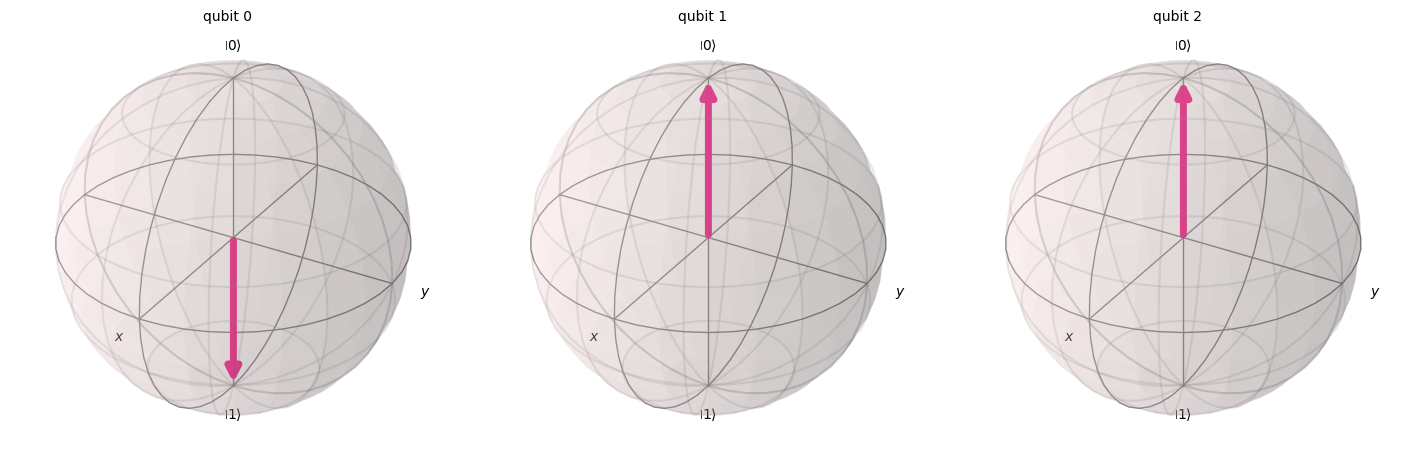

In [6]:
# Step 2: Define Initial 3-Qubit "Puzzle" State
# In this simplified model:
# |000⟩ → Solved puzzle state
# Other states (e.g. |001⟩, |010⟩, etc.) → Intermediate puzzle configurations

qc = QuantumCircuit(3, 3)

# Initialize the puzzle in a non-solved state |001⟩
qc.x(0)

print("=== Step 1: Initial 3-Puzzle State Circuit ===")
display(qc.draw('mpl'))

# Visualize the initial state on the Bloch sphere
state = Statevector.from_instruction(qc)
print("=== Bloch Vector of Initial State ===")
plot_bloch_multivector(state)

In [7]:
# Step 3: Define Quantum Production Rules
# Each "rule" represents a move in the puzzle,
# implemented here as a quantum NOT (X) gate on a specific qubit.

def apply_rule1(circuit):
    """Rule 1: Flip qubit 1 (simulate one type of move)."""
    circuit.x(1)
    return circuit

def apply_rule2(circuit):
    """Rule 2: Flip qubit 2 (simulate another move)."""
    circuit.x(2)
    return circuit

def apply_rule3(circuit):
    """Rule 3: Flip qubit 0 (simulate yet another move)."""
    circuit.x(0)
    return circuit


=== Step 2: Applying Rule 1 (Flip Qubit 1) ===


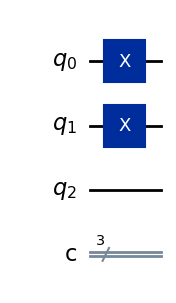

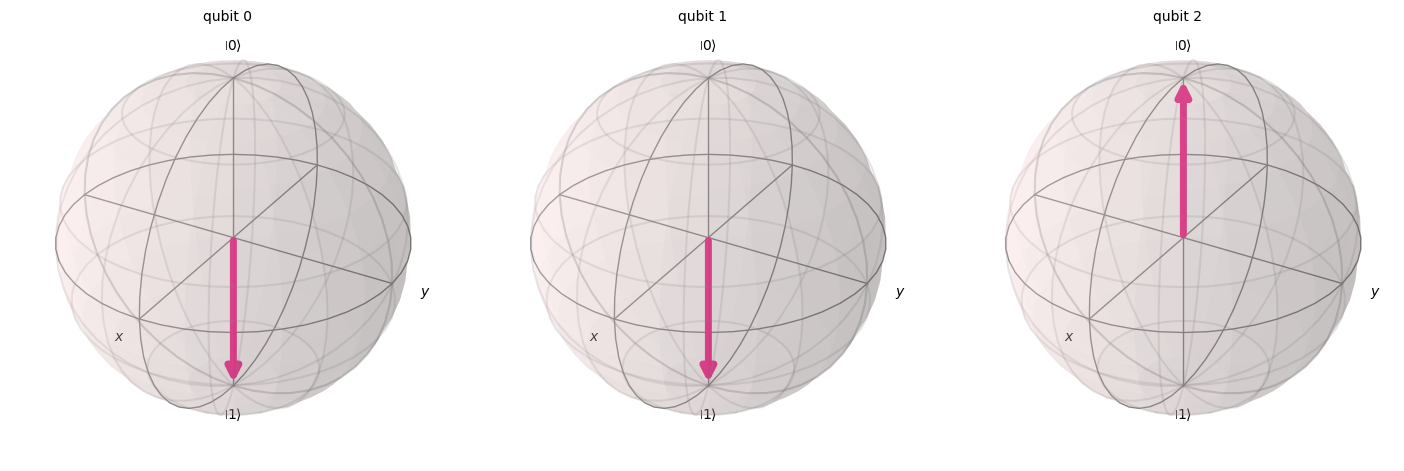

In [8]:
# Step 4: Apply Production Rules Step by Step

# --- Rule 1 ---
print("=== Step 2: Applying Rule 1 (Flip Qubit 1) ===")
qc_rule1 = qc.copy()
qc_rule1 = apply_rule1(qc_rule1)
display(qc_rule1.draw('mpl'))
state1 = Statevector.from_instruction(qc_rule1)
plot_bloch_multivector(state1)

=== Step 3: Applying Rule 2 (Flip Qubit 2) ===


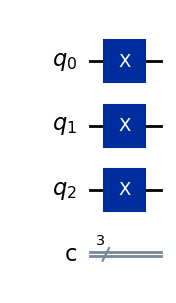

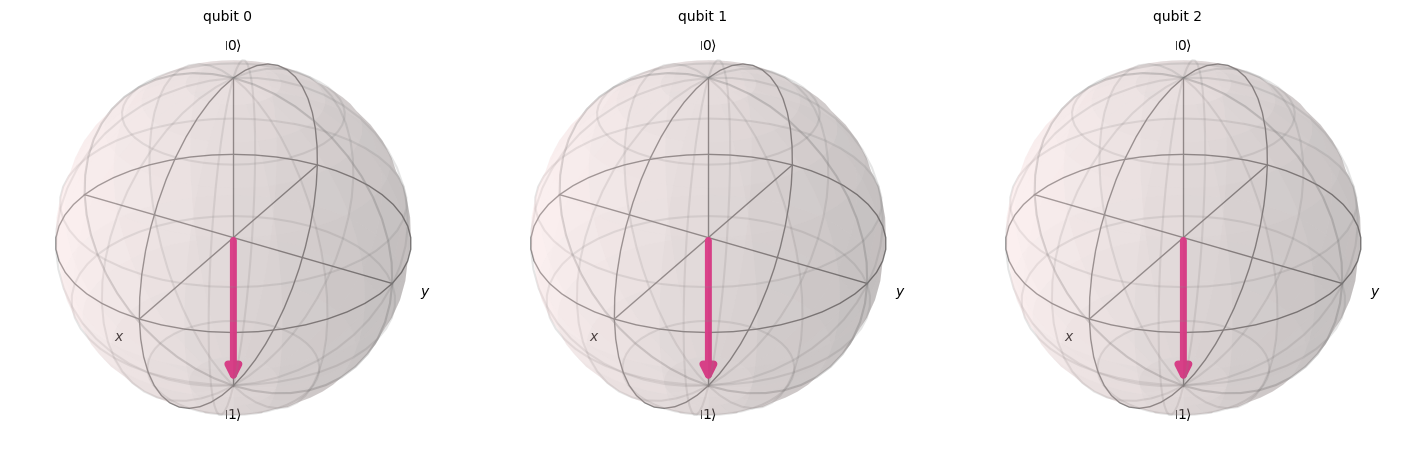

In [9]:
# --- Rule 2 ---
print("=== Step 3: Applying Rule 2 (Flip Qubit 2) ===")
qc_rule2 = qc_rule1.copy()
qc_rule2 = apply_rule2(qc_rule2)
display(qc_rule2.draw('mpl'))
state2 = Statevector.from_instruction(qc_rule2)
plot_bloch_multivector(state2)

=== Step 4: Applying Rule 3 (Flip Qubit 0) ===


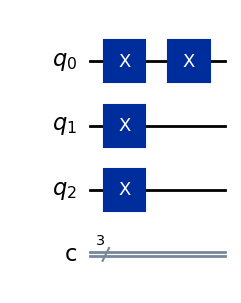

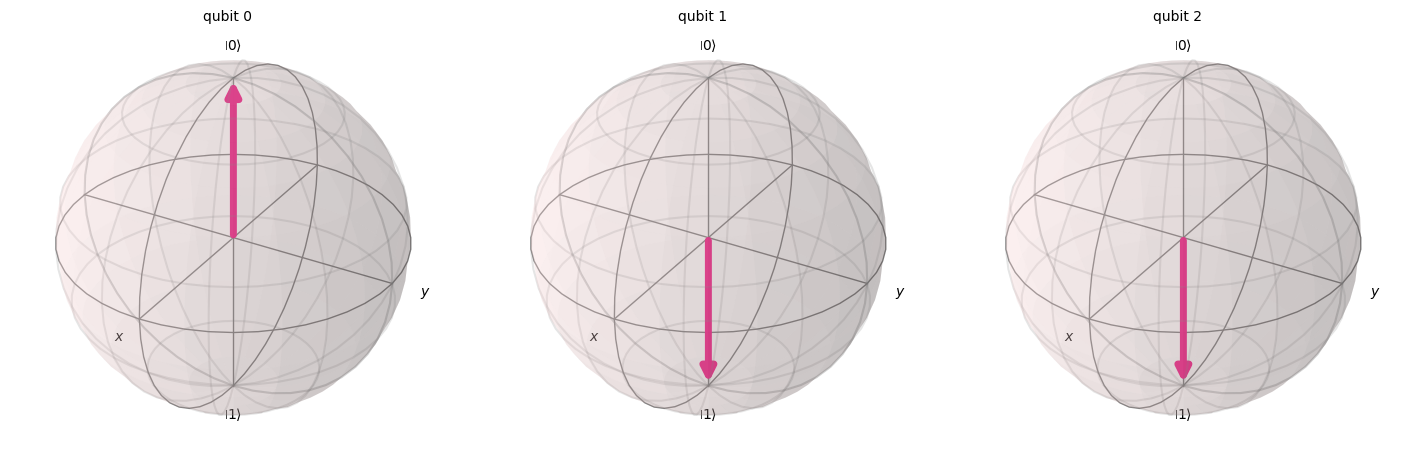

In [10]:
# --- Rule 3 ---
print("=== Step 4: Applying Rule 3 (Flip Qubit 0) ===")
qc_rule3 = qc_rule2.copy()
qc_rule3 = apply_rule3(qc_rule3)
display(qc_rule3.draw('mpl'))
state3 = Statevector.from_instruction(qc_rule3)
plot_bloch_multivector(state3)

=== Step 5: Final Circuit with Measurement ===


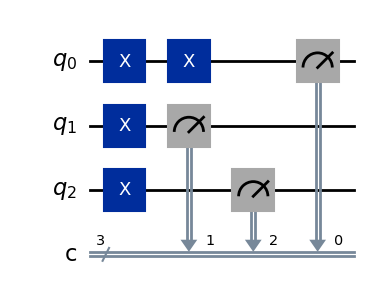

In [11]:
# Step 5: Measurement
# After all rules, measure all three qubits.
qc_final = qc_rule3.copy()
qc_final.measure([0, 1, 2], [0, 1, 2])

print("=== Step 5: Final Circuit with Measurement ===")
display(qc_final.draw('mpl'))

=== Step 6: Measurement Results (Manual Simulation) ===
{'110': 1024}


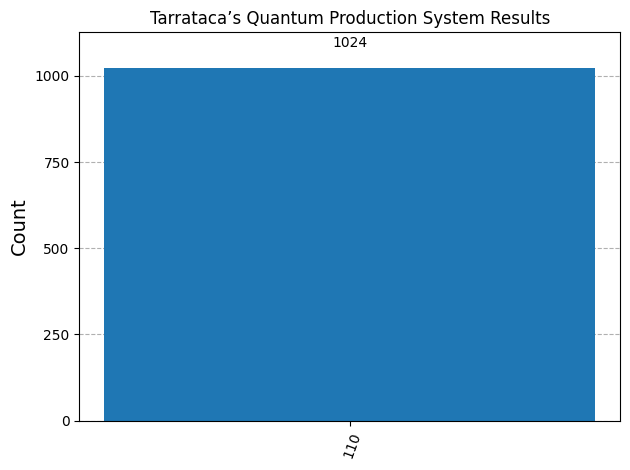

In [12]:
# =========================================================
# Step 6: Manual Simulation of Measurement
# =========================================================
# Instead of running QASM simulator, we'll simulate measurement manually
# to demonstrate the concept of "rule application → final state".

def manual_measure(start_state=[1, 0, 0], shots=1024):
    """
    Simulate final state after applying all three rules:
    Initial: |001⟩  (represented as [1,0,0] -> qubit0=1)
    Rule1: Flip qubit1
    Rule2: Flip qubit2
    Rule3: Flip qubit0
    """
    # Start from |001⟩ -> [1,0,0] (meaning qubit0 = 1)
    final_state = start_state.copy()
    
    # Apply rule 1, 2, 3 (bitwise XOR flip)
    final_state[1] ^= 1  # Rule1 flip
    final_state[2] ^= 1  # Rule2 flip
    final_state[0] ^= 1  # Rule3 flip
    
    # Convert to bitstring (rightmost = qubit0)
    key = "".join(str(bit) for bit in reversed(final_state))
    counts = {key: shots}
    return counts

counts = manual_measure(start_state=[1, 0, 0], shots=1024)

print("=== Step 6: Measurement Results (Manual Simulation) ===")
print(counts)
plot_histogram(counts, title="Tarrataca’s Quantum Production System Results")